<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula02c%20linear%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(20, 1) (20,)


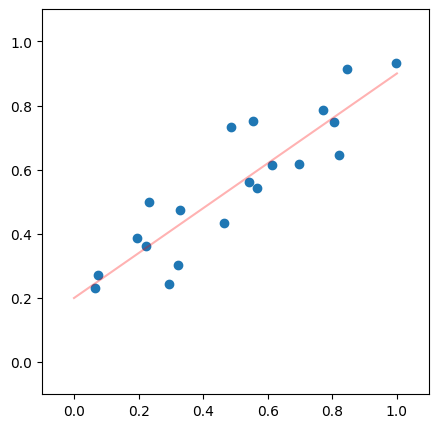

In [124]:
import numpy as np
import matplotlib.pyplot as plt

def createRegressionDataset(n=20):
  X = np.random.rand(n,1)
  coef = 0.7
  intercept = 0.2
  noise = np.random.randn(n,1) * 0.1
  y = X * coef + intercept + noise
  return X, y.reshape(-1)

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X, y)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

def plotLine(coef, intercept, color="red"):
  xs = np.array([0,1])
  ys = coef * xs + intercept
  plt.plot(xs, ys, c=color, alpha=0.3)

X, y = createRegressionDataset()
print(X.shape, y.shape)
plotDataset(X, y)
plotLine(0.7, 0.2)
plt.show()

RMSE: 0.0947927897015691
Weights: [0.70595911], Bias: 0.20361400617166964


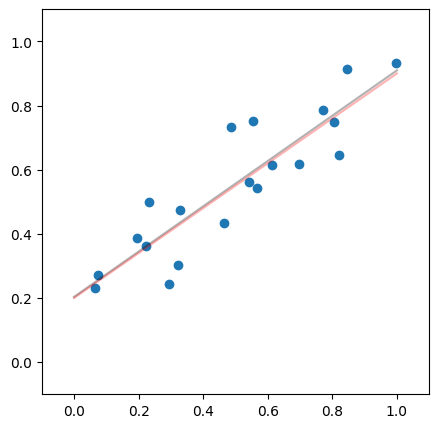

In [134]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import root_mean_squared_error

class LinearRegression(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=1000, learning_rate=0.01):
    self.max_iter = max_iter
    self.learning_rate = learning_rate

  def fit(self, X, y):
    self.w_ = np.random.rand(X.shape[1])
    self.b_ = np.random.rand()
    for _ in range(self.max_iter):
      cost = 0
      y_pred = self.predict(X)
      error = y - y_pred
      self.w_ += np.dot(X.T, error) * self.learning_rate
      self.b_ += np.sum(error) * self.learning_rate
      cost = np.sum(error**2)
      if cost == 0:
        break
    return self

  def predict(self, X):
    return X @ self.w_ + self.b_


clf = LinearRegression()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"RMSE: {root_mean_squared_error(y, y_pred)}")
print(f"Weights: {clf.w_}, Bias: {clf.b_}")
plotDataset(X, y)
plotLine(clf.w_, clf.b_, color="black")
plotLine(0.7, 0.2)
plt.show()

Accuracy: 0.897


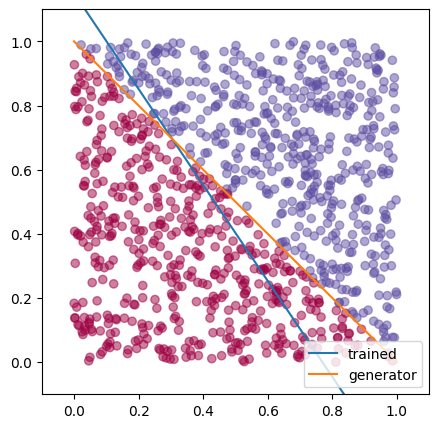

In [83]:
X_test, y_test = createDataset(1000)
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plotDataset(X_test, y_test)
plotHyperplan(clf.w_, clf.b_, legend="trained")
plotHyperplan(np.array([1, 1]), -1, legend="generator")
plt.show()